# Publication figures — finetune integration (finetune_threshold ablation)

Loads finetune trial results, groups by **trial name** (all parameters except seed), and plots mean ± SEM across seeds.

**Ablation figures** — one figure per **task** (`TASKS_TO_PLOT`: Passive, Active, Pooled):
- **Subplots** = neural conditions (Baseline-PER, Prioritization, Reward Augmentation, …)
- **Lines** = finetune threshold (`ft`) at fixed noise=0, β=1

**Summary** — optional figure with best curve per task × condition, selected by:
- **Reward** — highest returns (blend of peak and terminal performance)
- **Speed** — high reward reached in fewer evaluation checkpoints


In [49]:
import ast
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TASKS_TO_PLOT = ["Passive", "Active", "Pooled"]



In [50]:
DATA_FILE = "trial_results_finetuning_priority_aug_betafix.csv"
SEED_COLUMN = "parameters_experiment_random_state"
# "results_success_rate" or "results_total_reward" (reward is mean return per eval checkpoint)
METRIC = "results_total_reward" 
METRIC_LABELS = {
    "results_success_rate": "Evaluation success rate",
    "results_total_reward": "Mean evaluation return",
    "results_steps": "Steps at evaluation",
}
METRIC_LABEL = METRIC_LABELS[METRIC]
WINDOW_SIZE =  10
FINAL_WINDOW = 10
# Best-curve selection: reward (high y) + speed (fewer checkpoints to strong return)
CURVE_PEAK_WEIGHT = 0.5       # reward = blend of peak and terminal return
CURVE_REWARD_WEIGHT = 0.5     # weight on reward vs speed when picking best curve
CURVE_SPEED_WEIGHT = 0.5
SPEED_REACH_MARGIN = 1.0      # shared target = best peak in group minus this (reward points)

CONDITION_COLUMN = "parameters_experiment_condition"
TASK_COLUMN = "parameters_experiment_task"
NOISE_COLUMN = "parameters_mlp_model_noise"
BETA_COLUMN = "parameters_neural_beta"
FT_COLUMN = "parameters_experiment_finetune_threshold"

ABLATION_NOISE_BASELINE_BETA = 1.0
ABLATION_BETA_BASELINE_NOISE = 0.0
ABLATION_FT_BASELINE_NOISE = 0.0
ABLATION_FT_BASELINE_BETA = 1.0
ABLATION_CONDITION = "Baseline-PER"

CONDITION_ORDER = [
    "Baseline-PER", "Prioritization-PER", "Q-Augmentation-PER",
    "Reward Augmentation-PER", "All-PER",
]
TASK_ORDER = ["Passive", "Active", "Pooled"]
NOISE_ORDER = [0.0, 0.1, 0.5, 1.0]
BETA_ORDER = [0.5, 1.0, 5.0, 10.0]
FT_ORDER = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUMERIC_ABLATION_COLS = ("noise", "beta", "ft")
# Use tasks present in the CSV when AUTO_TASKS_FROM_DATA is True
AUTO_TASKS_FROM_DATA = True

SAVE_FIGURES = False
FIGURES_DIR = Path("figures_publication")


In [51]:
def resolve_data_path(filename: str) -> Path:
    here = Path.cwd()
    search_dirs = [here, here / "src" / "results"]
    for parent in [here, *here.parents]:
        candidate = parent / "src" / "results"
        if candidate.is_dir() and candidate not in search_dirs:
            search_dirs.append(candidate)
    for d in search_dirs:
        path = d / filename
        if path.is_file():
            return path
    raise FileNotFoundError(f"Could not find {filename}")


def read_results_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        return pd.read_csv(path, engine="python", on_bad_lines="skip")


PATH = resolve_data_path(DATA_FILE)
raw = read_results_csv(PATH)
print(f"Loaded {len(raw)} rows from {PATH}")


Loaded 8 rows from /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/trial_results_finetuning_priority_aug_betafix.csv


In [52]:
def make_trial_name(row: pd.Series) -> str:
    return (
        f"{row['parameters_experiment_domain']}__{row['parameters_experiment_task']}__"
        f"{row['parameters_experiment_condition']}__{row['parameters_experiment_integration_type']}__"
        f"{row['parameters_experiment_model_granularity']}__"
        f"noise{row[NOISE_COLUMN]}__beta{row[BETA_COLUMN]}__ft{row[FT_COLUMN]}"
    )


def parse_series(value) -> np.ndarray:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.array([], dtype=float)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except (SyntaxError, ValueError):
            return np.array([], dtype=float)
        return np.asarray(parsed, dtype=float)
    return np.asarray(value, dtype=float)


def parse_metric_series(row: pd.Series, metric_col: str) -> np.ndarray:
    arr = parse_series(row[metric_col])
    if metric_col != "results_total_reward" or len(arr) == 0:
        return arr

    # Training does all_total_rewards.extend(eval_reward) → 10 returns per eval,
    # while success_rate has one entry per eval. Align by chunking.
    if "results_success_rate" in row.index:
        n_checkpoints = len(parse_series(row["results_success_rate"]))
    else:
        n_checkpoints = 0

    if n_checkpoints > 0 and len(arr) % n_checkpoints == 0:
        chunk = len(arr) // n_checkpoints
        return np.nanmean(arr.reshape(n_checkpoints, chunk), axis=1)

    # Fallback (pretrain offline eval uses 10 episodes)
    chunk = 10
    n_checkpoints = len(arr) // chunk
    if n_checkpoints == 0:
        return arr
    return np.nanmean(arr[: n_checkpoints * chunk].reshape(n_checkpoints, chunk), axis=1)


def moving_average(arr: np.ndarray, window: int) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if window <= 1 or len(arr) < window:
        return arr
    csum = np.cumsum(np.nan_to_num(arr), dtype=float)
    csum[window:] = csum[window:] - csum[:-window]
    return csum[window - 1:] / window


def aggregate_seed_rows(rows: pd.DataFrame, metric_col: str, window: int):
    series = [
        moving_average(parse_metric_series(row, metric_col), window)
        for _, row in rows.iterrows()
    ]
    series = [s for s in series if len(s)]
    if not series:
        return np.array([]), np.array([]), 0
    max_len = max(len(s) for s in series)
    padded = [np.pad(s, (0, max_len - len(s)), constant_values=np.nan) for s in series]
    stacked = np.vstack(padded)
    n = stacked.shape[0]
    sem = np.nanstd(stacked, axis=0) / np.sqrt(n) if n > 0 else np.nanstd(stacked, axis=0)
    return np.nanmean(stacked, axis=0), sem, n


def sort_named(values, order: list):
    rank = {v: i for i, v in enumerate(order)}
    return sorted(values, key=lambda v: (rank.get(v, 999), str(v)))


def final_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    if len(mean_curve) == 0:
        return np.nan
    k = min(tail, len(mean_curve))
    return float(np.nanmean(mean_curve[-k:]))


def peak_reward(mean_curve: np.ndarray) -> float:
    if len(mean_curve) == 0:
        return np.nan
    return float(np.nanmax(mean_curve))


def reward_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    """Highest returns: blend of peak and terminal performance."""
    peak = peak_reward(mean_curve)
    terminal = final_score(mean_curve, tail)
    if not np.isfinite(peak):
        return terminal
    if not np.isfinite(terminal):
        return peak
    return float(CURVE_PEAK_WEIGHT * peak + (1.0 - CURVE_PEAK_WEIGHT) * terminal)


def _normalize_series(values: pd.Series) -> pd.Series:
    lo, hi = values.min(), values.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(1.0, index=values.index)
    return (values - lo) / (hi - lo)


def steps_to_reach(mean_curve: np.ndarray, threshold: float) -> int:
    """Absolute evaluation-checkpoint index when the curve first reaches ``threshold``."""
    y = np.asarray(mean_curve, dtype=float)
    if len(y) == 0:
        return 0
    hit = np.where(y >= threshold)[0]
    return int(hit[0]) if len(hit) else len(y)


def add_curve_scores(grp: pd.DataFrame) -> pd.DataFrame:
    """Score curves within a task × condition group.

  Speed uses the same reward target for every trial in the group (best peak − margin)
  and counts absolute checkpoints to reach it — run length does not inflate the score.
    """
    out = grp.copy()
    group_peak = float(out["peak_reward"].max())
    threshold = group_peak - SPEED_REACH_MARGIN
    out["reach_threshold"] = threshold
    out["steps_to_threshold"] = out["mean"].apply(lambda m: steps_to_reach(m, threshold))
    out["speed_score"] = out["peak_reward"] / (out["steps_to_threshold"] + 1)
    out["reward_norm"] = _normalize_series(out["reward_score"])
    out["speed_norm"] = _normalize_series(out["speed_score"])
    out["curve_score"] = (
        CURVE_REWARD_WEIGHT * out["reward_norm"] + CURVE_SPEED_WEIGHT * out["speed_norm"]
    )
    return out


raw["trial_name"] = raw.apply(make_trial_name, axis=1)
print(f"{raw['trial_name'].nunique()} unique trial names; "
      f"seeds/trial: {raw.groupby('trial_name')[SEED_COLUMN].nunique().median():.0f} median")

if AUTO_TASKS_FROM_DATA:
    present_tasks = sort_named(raw[TASK_COLUMN].dropna().unique().tolist(), TASK_ORDER)
    globals()["TASKS_TO_PLOT"] = present_tasks
    print(f"Tasks in data: {present_tasks}")


8 unique trial names; seeds/trial: 1 median
Tasks in data: ['Pooled']


In [53]:
def build_aggregated_table(df: pd.DataFrame, metric_col: str = METRIC) -> pd.DataFrame:
    records = []
    for trial_name, grp in df.groupby("trial_name", sort=False):
        mean, sem, n_seeds = aggregate_seed_rows(grp, metric_col, WINDOW_SIZE)
        rep = grp.iloc[0]
        records.append({
            "trial_name": trial_name,
            "mean": mean,
            "sem": sem,
            "n_seeds": n_seeds,
            "task": rep[TASK_COLUMN],
            "condition": rep[CONDITION_COLUMN],
            "noise": float(rep[NOISE_COLUMN]),
            "beta": float(rep[BETA_COLUMN]),
            "ft": float(rep[FT_COLUMN]),
            "peak_reward": peak_reward(mean),
            "final_score": final_score(mean),
            "reward_score": reward_score(mean),
        })
    return pd.DataFrame(records)


agg = build_aggregated_table(raw)
agg.head()


,trial_name,mean,sem,n_seeds,task,condition,noise,beta,ft,peak_reward,final_score,reward_score
0,Flappy__Pooled__Baseline-PER__finetune__binary...,"[3.3988, 4.164, 4.820399999999999, 5.829599999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,Pooled,Baseline-PER,0.0,1.0,0.0,47.8080,46.67380,47.24090
1,Flappy__Pooled__Baseline-PER__finetune__binary...,"[-2.0863999999999985, -0.9459999999999991, 0.1...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,Pooled,Baseline-PER,0.0,1.0,0.2,37.5564,36.35172,36.95406
2,Flappy__Pooled__Baseline-PER__finetune__binary...,"[2.175199999999999, 3.4063999999999988, 4.2019...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,Pooled,Baseline-PER,0.0,1.0,0.4,47.0292,43.81616,45.42268
3,Flappy__Pooled__Baseline-PER__finetune__binary...,"[2.7411999999999987, 3.6347999999999985, 3.631...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,Pooled,Baseline-PER,0.0,1.0,0.6,47.5732,41.28256,44.42788
4,Flappy__Pooled__Prioritization-PER__finetune__...,"[3.6871999999999994, 3.9547999999999988, 5.101...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,Pooled,Prioritization-PER,0.0,1.0,0.0,48.8664,48.68892,48.77766


In [54]:
def select_best_rows_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Return agg rows with the best curve_score per task × condition."""
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    picks = []
    for (_, _), grp in sub.groupby(["task", "condition"], sort=False):
        if grp.empty:
            continue
        scored = add_curve_scores(grp)
        valid = scored[scored["curve_score"].notna()]
        picks.append(valid.loc[valid["curve_score"].idxmax()] if not valid.empty else scored.iloc[0])
    if not picks:
        return pd.DataFrame()
    return pd.DataFrame(picks).reset_index(drop=True)


def select_best_ablations_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Summary table of best (noise, beta, ft) per task × condition."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        return best_rows
    return (
        best_rows.assign(
            best_noise=best_rows["noise"],
            best_beta=best_rows["beta"],
            best_ft=best_rows["ft"],
        )[
            [
                "task",
                "condition",
                "best_noise",
                "best_beta",
                "best_ft",
                "curve_score",
                "steps_to_threshold",
                "reach_threshold",
                "reward_score",
                "speed_score",
                "peak_reward",
                "final_score",
                "n_seeds",
                "trial_name",
            ]
        ]
        .sort_values(["task", "condition"])
        .reset_index(drop=True)
    )


FT_BEST_FILTERS = {
    "noise": ABLATION_FT_BASELINE_NOISE,
    "beta": ABLATION_FT_BASELINE_BETA,
}

best_ablations = select_best_ablations_per_task_condition(agg, filters=FT_BEST_FILTERS)
print("Best ablation per task × condition (ft sweep at noise=0, β=1):")
best_ablations


Best ablation per task × condition (ft sweep at noise=0, β=1):


,task,condition,best_noise,best_beta,best_ft,curve_score,steps_to_threshold,reach_threshold,reward_score,speed_score,peak_reward,final_score,n_seeds,trial_name
0,Pooled,Baseline-PER,0.0,1.0,0.0,1.0,83,46.8080,47.24090,0.569143,47.8080,46.67380,1,Flappy__Pooled__Baseline-PER__finetune__binary...
1,Pooled,Prioritization-PER,0.0,1.0,0.0,1.0,66,47.8664,48.77766,0.729349,48.8664,48.68892,1,Flappy__Pooled__Prioritization-PER__finetune__...


In [55]:
def plot_mean_sem(ax, mean, sem, label, color):
    if len(mean) == 0:
        return False
    x = np.arange(len(mean))
    #ax.plot(x, mean, label=label, color=color, alpha=0.6)
    ax.plot(x, mean, label=label, color=color, zorder=3, marker='o', markevery=500, markersize=6, markeredgecolor='white', markeredgewidth=0.8)
    if np.any(np.isfinite(sem)) and np.nanmax(sem) > 0:
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2, linewidth=0)
    return True


def publication_figure(
    table: pd.DataFrame,
    *,
    title: str,
    line_col: str,
    line_values: list,
    line_labels: list | None = None,
    subplot_col: str = "task",
    subplot_values: list | None = None,
    filters: dict | None = None,
    filename: str | None = None,
):
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    order = CONDITION_ORDER if subplot_col == "condition" else TASK_ORDER
    subplot_values = subplot_values or sort_named(sub[subplot_col].dropna().unique().tolist(), order)
    n = len(subplot_values)
    ncols = min(n, 2)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    match_line_to_subplot = line_col == subplot_col

    for i, subplot_val in enumerate(subplot_values):
        ax = axes[i]
        vals = [subplot_val] if match_line_to_subplot else line_values
        for j, line_val in enumerate(vals):
            if line_col in NUMERIC_ABLATION_COLS:
                mask = (sub[subplot_col] == subplot_val) & np.isclose(sub[line_col], line_val)
            else:
                mask = (sub[subplot_col] == subplot_val) & (sub[line_col] == line_val)
            row = sub[mask]
            if row.empty:
                continue
            r = row.iloc[0]
            label = (line_labels[j] if line_labels else str(line_val))
            label = f"{label} (n={int(r['n_seeds'])})"
            plot_mean_sem(ax, r["mean"], r["sem"], label, PALETTE[j % len(PALETTE)])

        ax.set_title(str(subplot_val))
        ax.set_xlabel("Evaluation checkpoint")
        if i % ncols == 0:
            ax.set_ylabel(METRIC_LABEL)
        ax.legend(frameon=False, loc="upper left")
        if METRIC == "results_success_rate":
            ax.set_ylim(bottom=-0.02, top=1.02)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    for j in range(len(subplot_values), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()

    # if SAVE_FIGURES and filename:
    #     FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    #     stem = Path(filename).stem
    #     for ext in (".pdf", ".png"):
    #         out = FIGURES_DIR / f"{stem}{ext}"
    #         fig.savefig(out)
    #         print(f"Saved {out}")

    plt.show()
    return fig


PALETTE = list(plt.cm.tab10.colors)


def slugify(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def tasks_to_plot() -> list:
    if TASKS_TO_PLOT is None:
        return list(TASK_ORDER)
    return [t for t in TASK_ORDER if t in TASKS_TO_PLOT]


def line_values_present(sub: pd.DataFrame, line_col: str, candidates: list) -> list:
    present = []
    for v in candidates:
        if line_col in NUMERIC_ABLATION_COLS:
            hit = sub[np.isclose(sub[line_col], v)]
        else:
            hit = sub[sub[line_col] == v]
        if not hit.empty:
            present.append(v)
    return present


def subplot_values_present(sub: pd.DataFrame, subplot_col: str, candidates: list) -> list:
    present = sort_named(sub[subplot_col].dropna().unique().tolist(), candidates)
    return present


def plot_ablation_for_each_task(
    table: pd.DataFrame,
    *,
    ablation_kind: str,
    min_lines: int = 2,
):
    """One figure per task; subplots = neural conditions; lines = ablation values."""
    if ablation_kind == "noise":
        fixed = {"beta": ABLATION_NOISE_BASELINE_BETA}
        line_col, candidates = "noise", NOISE_ORDER
        line_labels = [f"noise = {v}" for v in NOISE_ORDER]
        prefix = "ablation_model_noise"
        fixed_title = f"β = {ABLATION_NOISE_BASELINE_BETA}"
    elif ablation_kind == "beta":
        fixed = {"noise": ABLATION_BETA_BASELINE_NOISE}
        line_col, candidates = "beta", BETA_ORDER
        line_labels = [f"β = {v}" for v in BETA_ORDER]
        prefix = "ablation_neural_beta"
        fixed_title = f"noise = {ABLATION_BETA_BASELINE_NOISE}"
    elif ablation_kind in ("ft", "ff"):
        fixed = {"noise": ABLATION_FT_BASELINE_NOISE, "beta": ABLATION_FT_BASELINE_BETA}
        line_col, candidates = "ft", FT_ORDER
        line_labels = [f"ft = {v:g}" for v in FT_ORDER]
        prefix = "ablation_finetune_threshold"
        fixed_title = f"noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA}"
    else:
        raise ValueError("ablation_kind must be 'noise', 'beta', or 'ft'")

    for task in tasks_to_plot():
        filters = {"task": task, **fixed}
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        present = line_values_present(sub, line_col, candidates)
        if len(conditions) < 1 or len(present) < min_lines:
            print(f"Skip {task} ({ablation_kind}): {len(conditions)} conditions, {len(present)} ablation levels")
            continue

        present_labels = [line_labels[candidates.index(v)] for v in present]
        ablation_title = {
            "noise": "model noise",
            "beta": "neural β",
            "ft": "finetune threshold",
            "ff": "finetune threshold",
        }.get(ablation_kind, ablation_kind)
        publication_figure(
            table,
            title=f"{task} — {ablation_title} ablation ({fixed_title})",
            line_col=line_col,
            line_values=present,
            line_labels=present_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=f"{prefix}__{slugify(task)}.pdf",
        )


def plot_finetune_threshold_ablation(
    table: pd.DataFrame,
    *,
    min_lines: int = 1,
    tasks: list | None = None,
):
    """One figure per task; subplots = neural conditions; lines = finetune_threshold.

    Fixed at noise=0 and β=1 (see ABLATION_FT_BASELINE_* in config cell).
    """
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        ft_present = line_values_present(sub, "ft", FT_ORDER)
        if not conditions:
            print(f"Skip {task}: no conditions at noise=0, β=1")
            continue
        if len(ft_present) < min_lines:
            print(f"Skip {task}: only {len(ft_present)} finetune_threshold level(s) present")
            continue

        ft_labels = [f"ft = {v:g}" for v in ft_present]
        publication_figure(
            table,
            title=(
                f"{task} — finetune threshold ablation "
                f"(noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA})"
            ),
            line_col="ft",
            line_values=ft_present,
            line_labels=ft_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=f"ablation_finetune_threshold__{slugify(task)}.pdf",
        )


def plot_conditions_best_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
):
    """One figure: subplots = tasks; lines = conditions at each one's best (noise, β, ft)."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        print("Skip: no rows for per-condition best-ablation chart")
        return None

    tasks = [t for t in tasks_to_plot() if t in best_rows["task"].values]
    if not tasks:
        print("Skip: no tasks for per-condition best-ablation chart")
        return None

    n = len(tasks)
    ncols = min(n, 2)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, task in enumerate(tasks):
        ax = axes[i]
        task_rows = best_rows[best_rows["task"] == task]
        task_rows = task_rows.assign(
            _order=task_rows["condition"].map({c: i for i, c in enumerate(CONDITION_ORDER)})
        ).sort_values(["_order", "condition"])

        for j, (_, r) in enumerate(task_rows.iterrows()):
            label = (
                f"{r['condition']}\n"
                f"ft={r['ft']:g}, peak={r['peak_reward']:.1f}, "
                f"score={r['curve_score']:.2f} (n={int(r['n_seeds'])})"
            )
            plot_mean_sem(ax, r["mean"], r["sem"], label, PALETTE[j % len(PALETTE)])

        ax.set_title(task)
        ax.set_xlabel("Evaluation checkpoint")
        if i % ncols == 0:
            ax.set_ylabel(METRIC_LABEL)
        ax.legend(frameon=False, loc="upper left", fontsize=8)
        if METRIC == "results_success_rate":
            ax.set_ylim(bottom=-0.02, top=1.02)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    for j in range(len(tasks), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Best curves per condition — reward + speed ({METRIC_LABEL})",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()

    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        for ext in (".pdf", ".png"):
            out = FIGURES_DIR / f"conditions_best_per_task_condition{ext}"
            fig.savefig(out)
            print(f"Saved {out}")

    plt.show()
    return fig


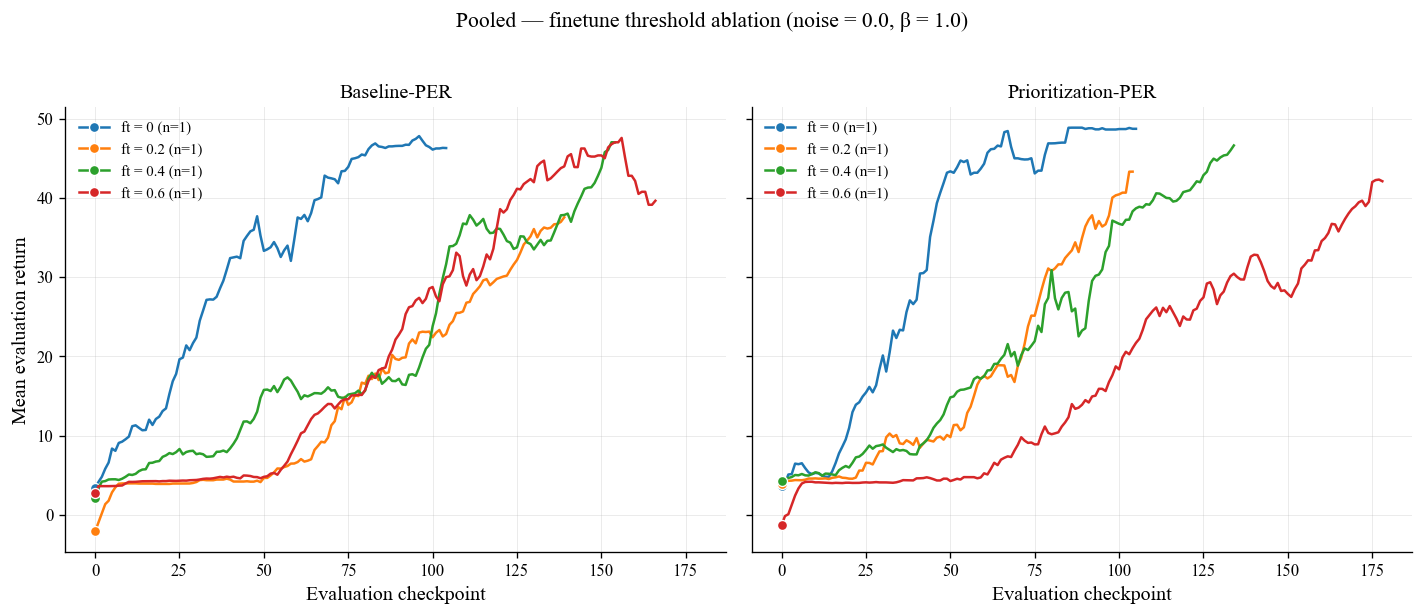

In [56]:
# --- Finetune-threshold ablation: one figure per task ---
# Subplots = neural conditions; lines = finetune_threshold (noise=0, β=1)
plot_finetune_threshold_ablation(agg, min_lines=1)


In [57]:
# Per condition × finetune_threshold: curve_score (reward + speed), plus peak & terminal return
ft_sub = agg[
    np.isclose(agg["noise"], ABLATION_FT_BASELINE_NOISE)
    & np.isclose(agg["beta"], ABLATION_FT_BASELINE_BETA)
]
ft_scored = pd.concat(
    [add_curve_scores(grp) for (_, _), grp in ft_sub.groupby(["task", "condition"], sort=False)],
    ignore_index=True,
)

ft_curve_summary = (
    ft_scored.pivot_table(index="condition", columns="ft", values="curve_score", aggfunc="first")
    .reindex(index=CONDITION_ORDER, columns=FT_ORDER)
)
ft_peak_summary = (
    ft_scored.pivot_table(index="condition", columns="ft", values="peak_reward", aggfunc="first")
    .reindex(index=CONDITION_ORDER, columns=FT_ORDER)
)
ft_final_summary = (
    ft_scored.pivot_table(index="condition", columns="ft", values="final_score", aggfunc="first")
    .reindex(index=CONDITION_ORDER, columns=FT_ORDER)
)

print("Curve score (normalized reward + speed) per condition × ft:")
display(ft_curve_summary)
print(f"Peak {METRIC_LABEL}:")
display(ft_peak_summary)
print(f"Terminal {METRIC_LABEL} (last {FINAL_WINDOW} checkpoints):")
display(ft_final_summary)


Curve score (normalized reward + speed) per condition × ft:


ft,0.0,0.2,0.4,0.6,0.8,1.0
condition,,,,,,
Baseline-PER,1.0,0.00000,0.476071,0.43026,NaN,NaN
Prioritization-PER,1.0,0.19508,0.405132,0.00000,NaN,NaN
Q-Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
Reward Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
All-PER,NaN,NaN,NaN,NaN,NaN,NaN


Peak Mean evaluation return:


ft,0.0,0.2,0.4,0.6,0.8,1.0
condition,,,,,,
Baseline-PER,47.8080,37.5564,47.0292,47.5732,NaN,NaN
Prioritization-PER,48.8664,43.3164,46.6220,42.3176,NaN,NaN
Q-Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
Reward Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
All-PER,NaN,NaN,NaN,NaN,NaN,NaN


Terminal Mean evaluation return (last 10 checkpoints):


ft,0.0,0.2,0.4,0.6,0.8,1.0
condition,,,,,,
Baseline-PER,46.67380,36.35172,43.81616,41.28256,NaN,NaN
Prioritization-PER,48.68892,39.96296,44.87716,40.38196,NaN,NaN
Q-Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
Reward Augmentation-PER,NaN,NaN,NaN,NaN,NaN,NaN
All-PER,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# One figure per finetune_threshold: lines = conditions (alternative view)
def plot_conditions_at_each_ft(table: pd.DataFrame, *, tasks: list | None = None):
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        ft_present = line_values_present(sub, "ft", FT_ORDER)
        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        if not ft_present or not conditions:
            print(f"Skip {task}: insufficient ft/condition data")
            continue

        publication_figure(
            table,
            title=(
                f"{task} — conditions across finetune thresholds "
                f"(noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA})"
            ),
            line_col="condition",
            line_values=conditions,
            subplot_col="ft",
            subplot_values=ft_present,
            filters=filters,
            filename=f"conditions_by_ft__{slugify(task)}.pdf",
        )


# Uncomment to plot the alternative layout:
# plot_conditions_at_each_ft(agg)


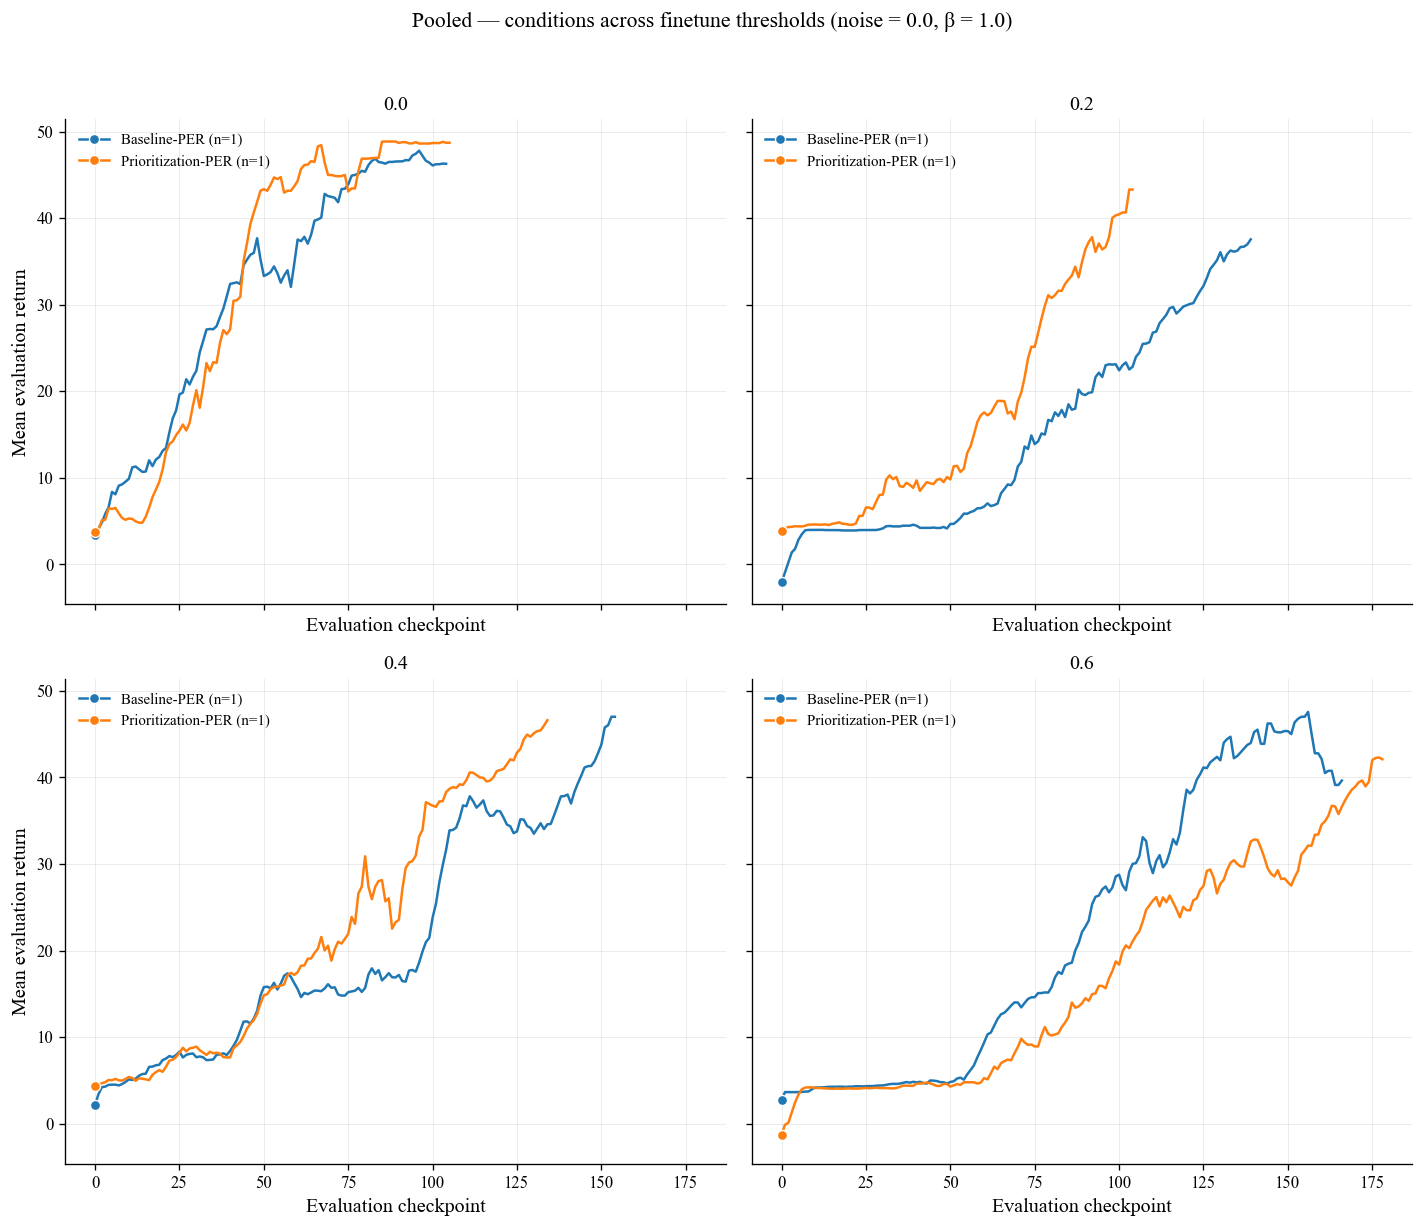

In [59]:
# Uncomment to plot the alternative layout:
plot_conditions_at_each_ft(agg)

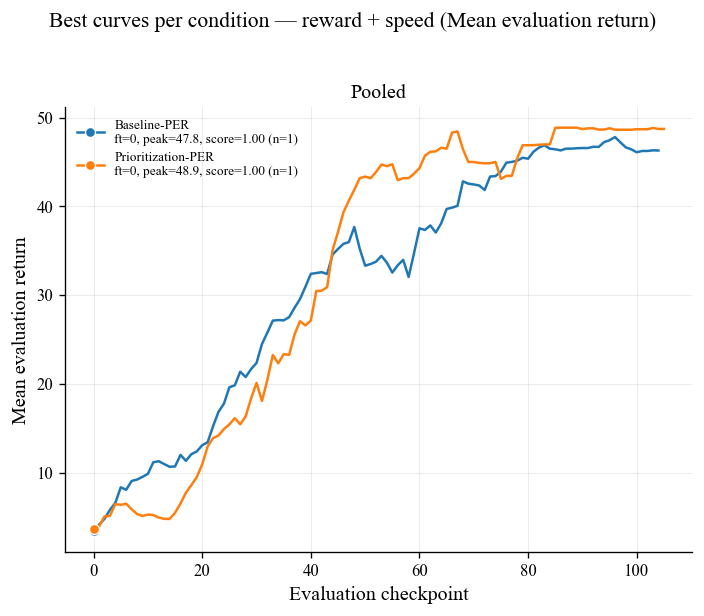

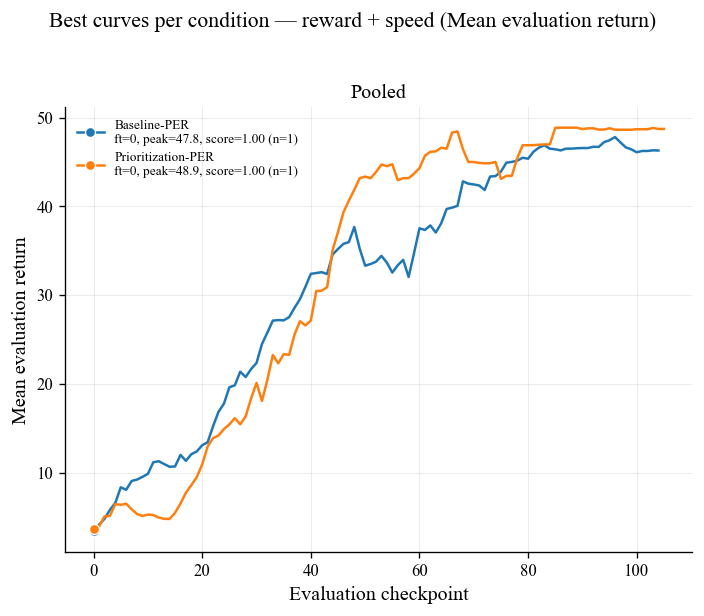

In [60]:
# Optional: best (noise, β, ft) per task × condition summary figure
plot_conditions_best_per_task_condition(agg, filters=FT_BEST_FILTERS)